# Cross-Session Evolution Analysis

This notebook analyzes how intent labels and complexity evolve across sessions at the repository level.

Core rules implemented in this notebook:
- Repository unit is `repo`.
- Sessions (`sha`) are ordered chronologically within each repository.
- Multi-label messages use equal fractional contribution for entropy calculation.
- Evolution is computed via normalized session position within each repo.
- Metrics include session length (# messages) and sub-category diversity (entropy).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import entropy

sns.set_theme(style="whitegrid")

# Paths and toggles
DATA_PATH = Path("../data/classifications/classifications_for_analysis.csv")
SAVE_RESULTS = False
RESULTS_DIR = Path("results")

# Analysis configuration
MIN_SESSIONS = 1  # Exclude repos with fewer than this many sessions.
SMOOTH_GRID_SIZE = (
    None  # Auto-set to max repo session count after repo stats are computed.
)
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

if SAVE_RESULTS:
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(
    f"Config -> MIN_SESSIONS={MIN_SESSIONS}, SAVE_RESULTS={SAVE_RESULTS}, "
    f"SMOOTH_GRID_SIZE=auto, DATA_PATH={DATA_PATH}"
)

Config -> MIN_SESSIONS=1, SAVE_RESULTS=False, SMOOTH_GRID_SIZE=auto, DATA_PATH=../data/classifications/classifications_for_analysis.csv


## 1) Load Data

Load classifications CSV and use `repository_full_name` as the repository identifier.

In [2]:
# Load classifications
clf = pd.read_csv(DATA_PATH)

required_cols = [
    "sha",
    "index_in_chat",
    "sub_category",
    "repository_full_name",
    "timestamp",
]
missing = [c for c in required_cols if c not in clf.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Rename repository_full_name to repo for consistency
clf = clf.rename(columns={"repository_full_name": "repo"})

# Parse timestamp for chronological ordering within each repo.
clf["timestamp"] = pd.to_datetime(clf["timestamp"], errors="coerce", utc=True)

print(
    f"Loaded {len(clf):,} label rows across {clf['sha'].nunique():,} sessions "
    f"and {clf['repo'].nunique():,} repos"
)
print(f"Missing timestamps: {clf['timestamp'].isna().sum():,}")

Loaded 99,415 label rows across 11,579 sessions and 1,300 repos
Missing timestamps: 0


## 2) Build Session-Level Base Table

This table is one row per session (sha) and includes:
- `session_msg_count`: number of messages in the session
- `repo`: repository identifier
- `sha`: session identifier

In [3]:
# Group by session to get unique messages
sess_base = clf.groupby(["repo", "sha", "index_in_chat"], as_index=False).size()
sess_base = sess_base.drop(columns=["size"])  # Just get unique combinations

# Count messages per session
session_msg_count = (
    sess_base.groupby(["repo", "sha"])["index_in_chat"]
    .nunique()
    .rename("session_msg_count")
    .reset_index()
)

# Build session-level timestamp (earliest message timestamp per session)
session_time = (
    clf.groupby(["repo", "sha"], as_index=False)["timestamp"]
    .min()
    .rename(columns={"timestamp": "session_time"})
)

session_msg_count = session_msg_count.merge(
    session_time, on=["repo", "sha"], how="left"
)

msg_stats = session_msg_count["session_msg_count"].describe()
print(
    f"Total sessions: {len(session_msg_count):,} | Missing session_time: "
    f"{session_msg_count['session_time'].isna().sum():,}"
)
print(
    f"Session length (min/median/mean/max): "
    f"{msg_stats['min']:.0f}/{msg_stats['50%']:.0f}/{msg_stats['mean']:.2f}/{msg_stats['max']:.0f}"
)

Total sessions: 11,579 | Missing session_time: 0
Session length (min/median/mean/max): 1/3/6.48/156


## 3) Filter Short Repos and Compute Normalized Session Position

Normalized position per repo:

$$
\text{pos\_norm} = \begin{cases}
  \frac{k}{m-1}, & m > 1 \\
  0, & m = 1
\end{cases}
$$

where $k$ is the zero-based rank of the session in chronological order (sorted by `session_time`, then `sha`), and $m$ is the repo's total session count.

In [4]:
# Count sessions per repo
repo_session_count = (
    session_msg_count.groupby("repo")["sha"]
    .nunique()
    .rename("repo_session_count")
    .reset_index()
)

# Filter to repos with enough sessions
valid_repos = set(
    repo_session_count.loc[
        repo_session_count["repo_session_count"] >= MIN_SESSIONS, "repo"
    ]
)

sess_f = session_msg_count[session_msg_count["repo"].isin(valid_repos)].copy()

n_total_repos = len(repo_session_count)
n_kept_repos = len(valid_repos)
print(f"Kept repos: {n_kept_repos:,} / {n_total_repos:,}")
print(
    f"Filtered out repos: {n_total_repos - n_kept_repos:,} (threshold={MIN_SESSIONS})"
)

Kept repos: 1,300 / 1,300
Filtered out repos: 0 (threshold=1)


In [5]:
# Compute normalized position per repo (chronological session order)
sess_f = sess_f.sort_values(
    ["repo", "session_time", "sha"], na_position="last"
).reset_index(drop=True)
sess_f["rank_in_repo"] = sess_f.groupby("repo").cumcount()
sess_f = sess_f.merge(repo_session_count, on="repo", how="left")

sess_f["pos_norm"] = np.where(
    sess_f["repo_session_count"] > 1,
    sess_f["rank_in_repo"] / (sess_f["repo_session_count"] - 1),
    0.0,
)

print(f"Sessions after filtering: {len(sess_f):,}")
print(
    f"pos_norm within [0, 1]: "
    f"{((sess_f['pos_norm'] >= 0) & (sess_f['pos_norm'] <= 1)).all()}"
)

Sessions after filtering: 11,579
pos_norm within [0, 1]: True


In [6]:
# Auto-set grid size
max_sessions_in_repo = int(sess_f["repo_session_count"].max()) if len(sess_f) else 2
SMOOTH_GRID_SIZE = max(2, max_sessions_in_repo)

repo_stats = (
    sess_f.groupby("repo")["repo_session_count"]
    .first()
    .describe(percentiles=[0.5, 0.9])
)
print(f"Auto grid size (max sessions in repo): {SMOOTH_GRID_SIZE}")
print(
    f"Sessions per repo (median/p90/max): "
    f"{repo_stats['50%']:.0f}/{repo_stats['90%']:.0f}/{repo_stats['max']:.0f}"
)

Auto grid size (max sessions in repo): 304
Sessions per repo (median/p90/max): 2/18/304


## 4) Compute Sub-Category Entropy for Each Session

For each session, we measure the diversity of sub-categories using Shannon entropy.
Multi-label messages contribute equally to all their labels (each label gets weight 1/labels_in_message).

Important normalization rule:
- Entropy is normalized by the global sub-category space size (all sub-categories in the dataset), not by the number of sub-categories observed in that session.
- This makes sessions that cover more distinct sub-categories score higher complexity, which matches the intended interpretation.

In [7]:
# Global sub-category space used for entropy normalization.
GLOBAL_SUBCATEGORIES = sorted(clf["sub_category"].dropna().unique().tolist())
GLOBAL_SUBCATEGORY_COUNT = len(GLOBAL_SUBCATEGORIES)


def compute_session_entropy(label_df: pd.DataFrame) -> float:
    """
    Compute Shannon entropy of sub-categories in a session.

    Multi-label messages: each label gets weight 1 / (# labels in message).
    Normalization: divide by log2(K_global), where K_global is the number of
    sub-categories in the full dataset, so broader coverage yields higher
    complexity than narrow-but-uniform sessions.
    """
    if len(label_df) == 0:
        return 0.0

    # Count labels per message (needed for normalization)
    msg_label_counts = label_df.groupby("index_in_chat").size().to_dict()

    # Assign fractional weight to each label
    label_df = label_df.copy()
    label_df["msg_labels"] = label_df["index_in_chat"].map(msg_label_counts)
    label_df["label_weight"] = 1.0 / label_df["msg_labels"]

    # Sum weights by sub-category and align to global category support.
    category_weights = (
        label_df.groupby("sub_category")["label_weight"]
        .sum()
        .reindex(GLOBAL_SUBCATEGORIES, fill_value=0.0)
        .to_numpy(dtype=float)
    )

    total_weight = category_weights.sum()
    if total_weight <= 0:
        return 0.0

    # Normalize to a probability distribution over global support.
    category_probs = category_weights / total_weight

    # Compute Shannon entropy (bits), then normalize by global maximum entropy.
    ent = entropy(category_probs, base=2)
    max_entropy = np.log2(max(2, GLOBAL_SUBCATEGORY_COUNT))
    normalized_entropy = ent / max_entropy if max_entropy > 0 else 0.0

    return float(normalized_entropy)


print(f"Global sub-category count: {GLOBAL_SUBCATEGORY_COUNT}")

Global sub-category count: 20


In [8]:
# Compute entropy for each session
entropy_results = []

for (repo, sha), group in clf.groupby(["repo", "sha"]):
    ent = compute_session_entropy(group)
    entropy_results.append({"repo": repo, "sha": sha, "entropy": ent})

entropy_df = pd.DataFrame(entropy_results)
ent_stats = entropy_df["entropy"].describe()

print(f"Entropies computed for {len(entropy_df):,} sessions")
print(
    f"Entropy (min/median/mean/max): "
    f"{ent_stats['min']:.4f}/{ent_stats['50%']:.4f}/{ent_stats['mean']:.4f}/{ent_stats['max']:.4f}"
)

Entropies computed for 11,579 sessions
Entropy (min/median/mean/max): 0.0000/0.3352/0.3130/0.8997


In [9]:
# Merge entropy into session table
sess_f = sess_f.merge(entropy_df, on=["repo", "sha"], how="left")

print(
    f"Session table with metrics: {len(sess_f):,} rows, "
    f"missing entropy: {sess_f['entropy'].isna().sum():,}"
)

Session table with metrics: 11,579 rows, missing entropy: 0


## 5) Build Session-Equal-Weight Interpolation Function

This is the core integration function: for each grid point, each repo contributes one interpolated value,
then we average across repos.

In [10]:
def repo_equal_weight_curve_from_sequences(
    sequences: dict[str, np.ndarray],
    grid_size: int,
) -> pd.DataFrame:
    """
    Compute grid curve where each repo contributes equally at each grid point.

    For each grid point g in [0, 1], each repo contributes one interpolated value.
    Final value is the simple average across repos (repo-equal weighting).
    Also returns cross-repo standard deviation at each grid point.
    """
    grid = np.linspace(0.0, 1.0, grid_size)
    if not sequences:
        return pd.DataFrame(
            {
                "pos_norm": grid,
                "value_raw_interp": np.zeros_like(grid),
                "value_smooth": np.zeros_like(grid),
                "value_std_interp": np.zeros_like(grid),
                "support_interp": np.zeros_like(grid),
            }
        )

    repo_vals = []
    for arr in sequences.values():
        y = np.asarray(arr, dtype=float)
        n = len(y)
        if n == 0:
            continue
        if n == 1:
            v = np.full_like(grid, y[0], dtype=float)
        else:
            u = grid * (n - 1)
            lo = np.floor(u).astype(int)
            hi = np.clip(lo + 1, 0, n - 1)
            alpha = u - lo
            v = (1.0 - alpha) * y[lo] + alpha * y[hi]
        repo_vals.append(v)

    if not repo_vals:
        return pd.DataFrame(
            {
                "pos_norm": grid,
                "value_raw_interp": np.zeros_like(grid),
                "value_smooth": np.zeros_like(grid),
                "value_std_interp": np.zeros_like(grid),
                "support_interp": np.zeros_like(grid),
            }
        )

    mat = np.vstack(repo_vals)
    mean_curve = mat.mean(axis=0)
    std_curve = mat.std(axis=0)
    support_curve = np.full_like(grid, fill_value=mat.shape[0], dtype=float)

    return pd.DataFrame(
        {
            "pos_norm": grid,
            "value_raw_interp": mean_curve,
            "value_smooth": mean_curve,
            "value_std_interp": std_curve,
            "support_interp": support_curve,
        }
    )


def build_repo_metric_sequences(
    session_df: pd.DataFrame, metric_col: str
) -> dict[str, np.ndarray]:
    """Build metric sequences indexed by repo."""
    out = {}
    for repo, g in session_df.sort_values(["repo", "rank_in_repo"]).groupby("repo"):
        out[repo] = g[metric_col].to_numpy(dtype=float)
    return out

## 6) Compute Evolution Curves for Both Metrics

Build sequences and interpolation curves for:
1. Session length (# messages)
2. Sub-category entropy (complexity)

In [11]:
# Session length evolution
session_len_sequences = build_repo_metric_sequences(
    sess_f, metric_col="session_msg_count"
)
session_len_curve = repo_equal_weight_curve_from_sequences(
    session_len_sequences, grid_size=SMOOTH_GRID_SIZE
)

session_len_exact = session_len_curve[
    ["pos_norm", "value_raw_interp", "support_interp"]
].copy()
session_len_exact = session_len_exact.rename(
    columns={"value_raw_interp": "mean_messages", "support_interp": "repos_at_pos"}
)

msg_curve_stats = session_len_exact["mean_messages"].describe()
print(
    f"Session length curve: {len(session_len_sequences)} repos, "
    f"grid_size={len(session_len_curve)}"
)
print(
    f"Mean messages (start/end): "
    f"{session_len_exact['mean_messages'].iloc[0]:.2f} -> "
    f"{session_len_exact['mean_messages'].iloc[-1]:.2f} | overall mean={msg_curve_stats['mean']:.2f}"
)

Session length curve: 1300 repos, grid_size=304
Mean messages (start/end): 10.08 -> 9.02 | overall mean=9.36


In [12]:
# Sub-category entropy (complexity) evolution
entropy_sequences = build_repo_metric_sequences(sess_f, metric_col="entropy")
entropy_curve = repo_equal_weight_curve_from_sequences(
    entropy_sequences, grid_size=SMOOTH_GRID_SIZE
)

entropy_exact = entropy_curve[["pos_norm", "value_raw_interp", "support_interp"]].copy()
entropy_exact = entropy_exact.rename(
    columns={"value_raw_interp": "mean_entropy", "support_interp": "repos_at_pos"}
)

entropy_curve_stats = entropy_exact["mean_entropy"].describe()
print(
    f"Entropy curve: {len(entropy_sequences)} repos, " f"grid_size={len(entropy_curve)}"
)
print(
    f"Mean entropy (start/end): "
    f"{entropy_exact['mean_entropy'].iloc[0]:.4f} -> "
    f"{entropy_exact['mean_entropy'].iloc[-1]:.4f} | overall mean={entropy_curve_stats['mean']:.4f}"
)

Entropy curve: 1300 repos, grid_size=304
Mean entropy (start/end): 0.3897 -> 0.3544 | overall mean=0.3705


## 7) Linear Trend Quantification

Run linear regression for each metric with normalized position as X and curve value as Y,
to quantify the trend magnitude and significance.

Implementation note: the regression uses a uniform grid in [0, 1],
which matches the `pos_norm` interpolation grid used to build the evolution curves.

In [13]:
def regression_report_single_curve(
    curve: pd.DataFrame, metric_name: str
) -> pd.DataFrame:
    """Run linear regression on a single evolution curve."""
    y = curve["value_smooth"].to_numpy(dtype=float)
    x = np.linspace(0, 1, len(y))
    slope, intercept, r, p, se = stats.linregress(x, y)
    return pd.DataFrame(
        [
            {
                "metric": metric_name,
                "slope": slope,
                "r_squared": r**2,
                "p_value": p,
                "intercept": intercept,
                "std_err": se,
            }
        ]
    )


session_len_trend = regression_report_single_curve(
    session_len_curve, "session_length_messages"
)
entropy_trend = regression_report_single_curve(entropy_curve, "complexity_entropy")

trend_report = pd.concat([session_len_trend, entropy_trend], ignore_index=True)

print("Evolution Trend Report:")
print(trend_report.to_string())

Evolution Trend Report:
                    metric     slope  r_squared        p_value  intercept   std_err
0  session_length_messages -0.834809   0.846266  7.943143e-125   9.776162  0.020475
1       complexity_entropy -0.024435   0.946101  1.387304e-193   0.382687  0.000336


## 8) Visualization

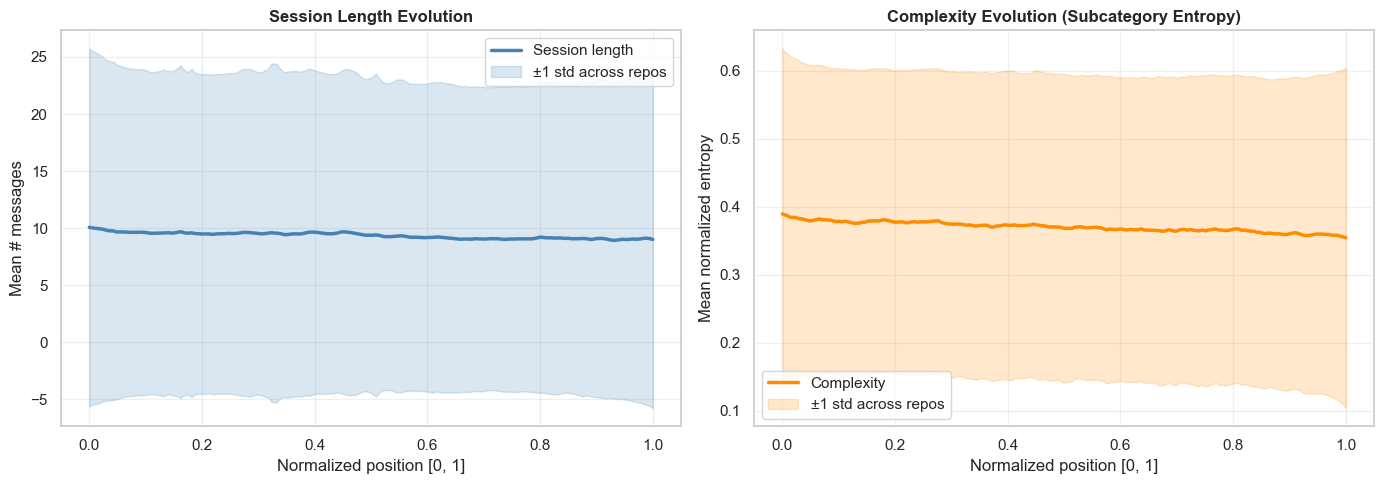

In [14]:
# Combined comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Session length
axes[0].plot(
    session_len_curve["pos_norm"],
    session_len_curve["value_smooth"],
    linewidth=2.5,
    color="steelblue",
    label="Session length",
)
axes[0].fill_between(
    session_len_curve["pos_norm"],
    session_len_curve["value_smooth"] - session_len_curve["value_std_interp"],
    session_len_curve["value_smooth"] + session_len_curve["value_std_interp"],
    alpha=0.2,
    color="steelblue",
    label="±1 std across repos",
)
axes[0].set_title("Session Length Evolution", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Normalized position [0, 1]")
axes[0].set_ylabel("Mean # messages")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Entropy
axes[1].plot(
    entropy_curve["pos_norm"],
    entropy_curve["value_smooth"],
    linewidth=2.5,
    color="darkorange",
    label="Complexity",
)
axes[1].fill_between(
    entropy_curve["pos_norm"],
    entropy_curve["value_smooth"] - entropy_curve["value_std_interp"],
    entropy_curve["value_smooth"] + entropy_curve["value_std_interp"],
    alpha=0.2,
    color="darkorange",
    label="±1 std across repos",
)
axes[1].set_title(
    "Complexity Evolution (Subcategory Entropy)", fontsize=12, fontweight="bold"
)
axes[1].set_xlabel("Normalized position [0, 1]")
axes[1].set_ylabel("Mean normalized entropy")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 9) Summary Statistics

In [15]:
summary_stats = pd.DataFrame(
    [
        {"metric": "Total repositories (filtered)", "value": n_kept_repos},
        {"metric": "Filtered out repositories", "value": n_total_repos - n_kept_repos},
        {"metric": "Total sessions (filtered)", "value": len(sess_f)},
        {"metric": "Total labels in data", "value": len(clf)},
        {
            "metric": "Min session length (messages)",
            "value": int(sess_f["session_msg_count"].min()),
        },
        {
            "metric": "Max session length (messages)",
            "value": int(sess_f["session_msg_count"].max()),
        },
        {
            "metric": "Mean session length (messages)",
            "value": f"{sess_f['session_msg_count'].mean():.2f}",
        },
        {"metric": "Min entropy", "value": f"{sess_f['entropy'].min():.4f}"},
        {"metric": "Max entropy", "value": f"{sess_f['entropy'].max():.4f}"},
        {"metric": "Mean entropy", "value": f"{sess_f['entropy'].mean():.4f}"},
    ]
)

print("\nSummary Statistics:")
print(summary_stats.to_string(index=False))


Summary Statistics:
                        metric  value
 Total repositories (filtered)   1300
     Filtered out repositories      0
     Total sessions (filtered)  11579
          Total labels in data  99415
 Min session length (messages)      1
 Max session length (messages)    156
Mean session length (messages)   6.48
                   Min entropy 0.0000
                   Max entropy 0.8997
                  Mean entropy 0.3130


## 10) Optional Export

Export results to CSV if `SAVE_RESULTS = True`.

In [16]:
if SAVE_RESULTS:
    session_len_exact.to_csv(RESULTS_DIR / "session_length_evolution.csv", index=False)
    entropy_exact.to_csv(RESULTS_DIR / "complexity_entropy_evolution.csv", index=False)
    trend_report.to_csv(RESULTS_DIR / "evolution_trends.csv", index=False)
    summary_stats.to_csv(RESULTS_DIR / "cross_session_summary.csv", index=False)
    print(f"Saved outputs to: {RESULTS_DIR.resolve()}")
else:
    print("SAVE_RESULTS is False. No files were written.")

SAVE_RESULTS is False. No files were written.


## 11) Interpretation Guide

Use this section after running all cells to analyze results:

1. **Session Length Trend**: Does the average number of messages per session increase or decrease across a repository's lifetime?
   - Positive slope: sessions become longer (more elaborate interactions)
   - Negative slope: sessions become shorter (more focused, direct interactions)

2. **Complexity (Entropy) Trend**: How does sub-category diversity change across a repository's evolution?
   - Positive slope: later sessions explore more diverse intent categories (broader scope)
   - Negative slope: later sessions focus on fewer categories (narrower scope)
   - Flat trend: consistent engagement patterns across the repository lifecycle

3. **Statistical Significance**: Check p-values in the trend report:
   - p < 0.05: trend is statistically significant
   - p ≥ 0.05: trend is not significantly different from random variation